<a href="https://colab.research.google.com/github/Neha-Sharma7/Face-Recognition-System/blob/main/Face_Recognition_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy scikit-learn opencv-python matplotlib

In [ ]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
def load_orl_dataset(path):
    images = []
    labels = []

    for person_folder in os.listdir(path):
        person_path = os.path.join(path, person_folder)

        if not os.path.isdir(person_path):
            continue

        label = int(person_folder.replace("s", ""))  # s1 → 1

        for file in os.listdir(person_path):
            img_path = os.path.join(person_path, file)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (92, 112))
            images.append(img.flatten())
            labels.append(label)

    return np.array(images), np.array(labels)

In [ ]:
dataset_path = "/content/drive/MyDrive/archive (1)"  # FIX THIS PATH

X, y = load_orl_dataset(dataset_path)

print("Dataset loaded:", X.shape, y.shape)


Dataset loaded: (400, 10304) (400,)


In [ ]:
print(os.listdir(dataset_path)[:5])

['s23', 's26', 's5', 's31', 's9']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
unique_people = sorted(list(set(y)))

train_X, train_y = [], []
test_X, test_y = [], []

for person in unique_people:
    person_images = X[y == person]

    train_X.extend(person_images[:5])
    test_X.extend(person_images[5:])

    train_y.extend([person]*5)
    test_y.extend([person]*5)

train_X = np.array(train_X)
test_X = np.array(test_X)
train_y = np.array(train_y)
test_y = np.array(test_y)

print("Train:", train_X.shape, "Test:", test_X.shape)

Train: (200, 10304) Test: (200, 10304)


In [ ]:
# Safety reshape (important)
train_X = train_X.reshape(train_X.shape[0], -1)
test_X = test_X.reshape(test_X.shape[0], -1)

n_components = 80

pca = PCA(n_components=n_components, whiten=True, random_state=42)

train_pca = pca.fit_transform(train_X)
test_pca = pca.transform(test_X)

print("PCA completed:", train_pca.shape)

PCA completed: (200, 80)


In [ ]:
clf = SVC(kernel="linear", probability=True)
clf.fit(train_pca, train_y)

SVC(kernel='linear', probability=True)

In [ ]:
preds = clf.predict(test_pca)

acc = accuracy_score(test_y, preds)
print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 94.00%


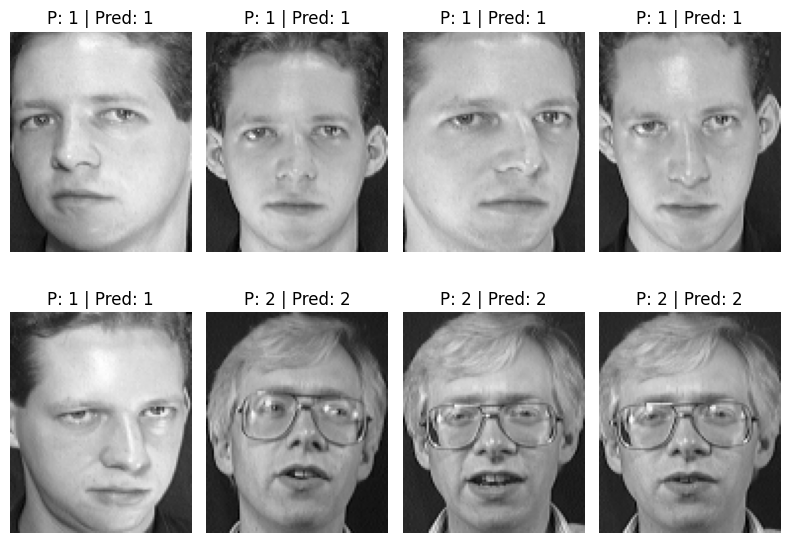

In [ ]:
plt.figure(figsize=(8,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(test_X[i].reshape(112,92), cmap='gray')
    plt.axis('off')
    plt.title(f"P: {test_y[i]} | Pred: {preds[i]}")

plt.tight_layout()
plt.show()

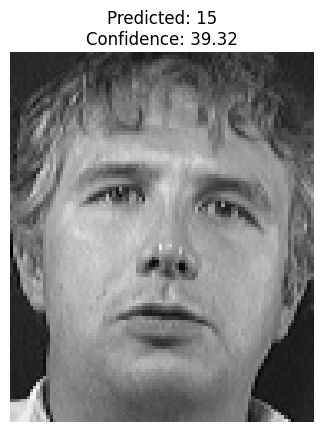

Predicted Person: 15
Confidence score: 39.32


In [ ]:
test_image_path = "/content/drive/MyDrive/archive (1)/s15/3.pgm"

img = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (92,112))

img_flat = img.flatten().reshape(1, -1)
img_pca = pca.transform(img_flat)

pred_label = clf.predict(img_pca)[0]

decision_scores = clf.decision_function(img_pca)
confidence = np.max(decision_scores)

plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {pred_label}\nConfidence: {confidence:.2f}")
plt.axis('off')
plt.show()

print("Predicted Person:", pred_label)
print(f"Confidence score: {confidence:.2f}")